# Airbnb London — Mismatch vs Quality-Deficiency Analysis**Goal:** Classify negative Airbnb reviews as *mismatch* (property didn't fit guestexpectations despite adequate quality) or *quality deficiency* (genuine qualityproblems), using:1. VADER sentiment detection (fast, rule-based)2. Rule-based aspect tagging with validated regex3. Listing-level quality proxies & complaint recurrence4. **GPU-accelerated PyTorch text classifier** to resolve unclear labelsAll heavy computation runs on CUDA when available.

In [1]:
from __future__ import annotations
import json, re, time, warnings
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from wordcloud import WordCloud, STOPWORDS

warnings.filterwarnings("ignore", category=UserWarning)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"PyTorch {torch.__version__}  |  Device: {DEVICE}")
if DEVICE.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}  "
          f"({torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB)")

PyTorch 2.6.0+cu124  |  Device: cuda
GPU: NVIDIA GeForce RTX 3050 Laptop GPU  (4.0 GB)


## 1  Configuration

In [2]:
DATA_DIR = Path("data/data")
OUTPUT_DIR = Path("airbnb_mismatch_outputs")
FIGURES_DIR = Path("figures")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

NOTES_PATH = DATA_DIR / "notes.csv"

NEGATIVE_THRESHOLD     = -0.05
HIGH_QUALITY_THRESHOLD = 4.7
LOW_QUALITY_THRESHOLD  = 4.4
RECURRENCE_THRESHOLD   = 0.15
EXAMPLES_PER_LABEL     = 20
MODEL_CONFIDENCE       = 0.70

print(f"Data path : {NOTES_PATH}  (exists: {NOTES_PATH.exists()})")
print(f"Outputs   : {OUTPUT_DIR}")

Data path : data\data\notes.csv  (exists: True)
Outputs   : airbnb_mismatch_outputs


## 2  Aspect Dictionaries & Regex Patterns

In [3]:
QUALITY_ASPECTS = {
    "cleanliness": [
        "dirty", "filthy", "dust", "dusty", "stain", "stained", "mold",
        "mould", "smell", "odor", "odour", "hair", "unclean",
        "cleanliness", "bugs", "bug",
    ],
    "maintenance": [
        "broken", "leak", "leaking", "heater", "heating", "shower",
        "toilet", "wifi", "internet", "bedbug", "bedbugs", "malfunction",
        "repair", "air conditioning", "hot water",
    ],
    "host_service": [
        "rude", "unhelpful", "unresponsive", "late", "cancel", "canceled",
        "cancelled", "host never replied", "host did not reply",
        "communication", "check in", "check-in", "keys",
    ],
    "accuracy_safety": [
        "misleading", "not as described", "different from photos",
        "different than photos", "unsafe", "dangerous", "lock", "scam",
        "fraud", "inaccurate", "accuracy",
    ],
}

MISMATCH_ASPECTS = {
    "location_fit": [
        "far", "distance", "commute", "tube", "transport", "location",
        "neighbourhood", "neighborhood", "area", "central", "zone",
    ],
    "space_fit": [
        "small", "tiny", "cramped", "stairs", "steep", "space", "layout",
        "narrow", "compact",
    ],
    "value_fit": [
        "expensive", "overpriced", "pricey", "value", "worth",
        "not worth", "too much", "cost",
    ],
    "preference_fit": [
        "noisy", "noise", "loud", "firm bed", "soft bed", "hot", "cold",
        "light sleeper", "dark",
    ],
}

ALL_PATTERNS = {}
for group in (QUALITY_ASPECTS, MISMATCH_ASPECTS):
    for key, terms in group.items():
        joined = "|".join(re.escape(t) for t in terms)
        ALL_PATTERNS[key] = re.compile(r"\b(?:" + joined + r")\b", re.IGNORECASE)

QUALITY_SCORE_MAP = {
    "cleanliness":    "review_scores_cleanliness",
    "host_service":   "review_scores_communication",
    "accuracy_safety":"review_scores_accuracy",
    "location_fit":   "review_scores_location",
    "value_fit":      "review_scores_value",
}

print(f"Compiled {len(ALL_PATTERNS)} aspect patterns (non-capturing groups)")

Compiled 8 aspect patterns (non-capturing groups)


## 3  Data Loading & Preparation

In [4]:
def parse_percent(s: pd.Series) -> pd.Series:
    c = s.astype(str).str.replace("%", "", regex=False).str.strip()
    c = c.replace({"nan": np.nan, "None": np.nan})
    return pd.to_numeric(c, errors="coerce")

def parse_price(s: pd.Series) -> pd.Series:
    c = s.astype(str).str.replace("$", "", regex=False).str.replace(",", "", regex=False).str.strip()
    c = c.replace({"nan": np.nan, "None": np.nan})
    return pd.to_numeric(c, errors="coerce")

def prepare_data(path: Path) -> pd.DataFrame:
    usecols = [
        "listing_id", "reviewer_id", "comments", "text", "room_type",
        "price", "host_response_rate", "host_is_superhost", "instant_bookable",
        "review_scores_rating", "review_scores_accuracy",
        "review_scores_cleanliness", "review_scores_communication",
        "review_scores_location", "review_scores_value",
    ]
    t0 = time.time()
    df = pd.read_csv(path, usecols=usecols, low_memory=False)
    print(f"  Loaded {len(df):,} rows in {time.time()-t0:.1f}s")

    text_col = "comments" if "comments" in df.columns else "text"
    df["review_text"] = (
        df[text_col].fillna(df.get("text", "")).fillna("")
        .astype(str).str.replace(r"\s+", " ", regex=True).str.strip()
    )
    df = df[df["review_text"].ne("")].copy()

    score_cols = [
        "review_scores_rating", "review_scores_accuracy",
        "review_scores_cleanliness", "review_scores_communication",
        "review_scores_location", "review_scores_value",
    ]
    for col in score_cols:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    df["host_response_rate_num"] = parse_percent(df["host_response_rate"])
    df["price_num"] = parse_price(df["price"])
    df["host_is_superhost_num"] = df["host_is_superhost"].map({"t": 1, "f": 0})
    df["instant_bookable_num"] = df["instant_bookable"].map({"t": 1, "f": 0})
    print(f"  After cleaning: {len(df):,} reviews")
    return df

t_start = time.time()
df = prepare_data(NOTES_PATH)
print(f"  Total prep time: {time.time()-t_start:.1f}s")

  Loaded 2,097,996 rows in 79.9s


  After cleaning: 2,097,795 reviews
  Total prep time: 98.0s


## 4  Sentiment Scoring (VADER — batched)

In [5]:
def score_sentiment(df: pd.DataFrame) -> pd.DataFrame:
    analyzer = SentimentIntensityAnalyzer()
    texts = df["review_text"].tolist()

    t0 = time.time()
    scores = [analyzer.polarity_scores(t)["compound"] for t in texts]
    elapsed = time.time() - t0
    print(f"  VADER scored {len(texts):,} reviews in {elapsed:.1f}s "
          f"({len(texts)/elapsed:,.0f} reviews/sec)")

    df = df.copy()
    df["vader_compound"] = scores
    return df

df = score_sentiment(df)

neg_pct = (df["vader_compound"] <= NEGATIVE_THRESHOLD).mean() * 100
print(f"  Negative reviews: {neg_pct:.1f}%")

  VADER scored 2,097,795 reviews in 577.0s (3,636 reviews/sec)


  Negative reviews: 5.0%


## 5  Aspect Tagging

In [6]:
def tag_aspects(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    lowered = df["review_text"].str.lower()

    t0 = time.time()
    for name, pattern in ALL_PATTERNS.items():
        df[f"tag_{name}"] = lowered.str.contains(pattern, na=False).astype(np.int8)
    print(f"  Tagged {len(ALL_PATTERNS)} aspects in {time.time()-t0:.1f}s")
    return df

df = tag_aspects(df)

tag_cols = [c for c in df.columns if c.startswith("tag_")]
tag_means = df[tag_cols].mean().mul(100).round(2)
print("  Aspect prevalence (% of all reviews):")
for name, val in tag_means.items():
    print(f"    {name:30s} {val:5.2f}%")

  Tagged 8 aspects in 7.9s
  Aspect prevalence (% of all reviews):
    tag_cleanliness                 1.65%
    tag_maintenance                 5.32%
    tag_host_service               12.27%
    tag_accuracy_safety             0.57%
    tag_location_fit               43.92%
    tag_space_fit                   9.84%
    tag_value_fit                   4.09%
    tag_preference_fit              4.71%


## 6  Listing Context & Classification

In [7]:
def build_listing_context(df: pd.DataFrame) -> pd.DataFrame:
    quality_cols = [
        "review_scores_rating", "review_scores_accuracy",
        "review_scores_cleanliness", "review_scores_communication",
        "review_scores_location", "review_scores_value",
    ]
    extra = ["host_response_rate_num", "host_is_superhost_num", "instant_bookable_num"]
    listing_quality = (
        df.groupby("listing_id")[quality_cols + extra]
        .mean(numeric_only=True)
        .rename(columns=lambda c: f"listing_{c}")
    )

    neg_mask = df["vader_compound"] <= NEGATIVE_THRESHOLD
    tag_cols = [c for c in df.columns if c.startswith("tag_")]
    recurrence = (
        df.loc[neg_mask].groupby("listing_id")[tag_cols]
        .mean()
        .rename(columns=lambda c: f"recurrence_{c[4:]}")
    )
    return listing_quality.join(recurrence, how="left").fillna(0)

listing_context = build_listing_context(df)
print(f"  Listing context built for {len(listing_context):,} listings")

  Listing context built for 72,749 listings


In [8]:
def classify_reviews(
    df: pd.DataFrame,
    listing_context: pd.DataFrame,
) -> pd.DataFrame:
    """Fully vectorized classification — no iterrows."""
    t0 = time.time()
    df = df.join(listing_context, on="listing_id")
    df["is_negative_review"] = df["vader_compound"] <= NEGATIVE_THRESHOLD

    quality_tag_cols = [f"tag_{n}" for n in QUALITY_ASPECTS]
    mismatch_tag_cols = [f"tag_{n}" for n in MISMATCH_ASPECTS]

    df["quality_tag_count"] = df[quality_tag_cols].sum(axis=1)
    df["mismatch_tag_count"] = df[mismatch_tag_cols].sum(axis=1)

    listing_score_cols = [
        "listing_review_scores_rating", "listing_review_scores_accuracy",
        "listing_review_scores_cleanliness", "listing_review_scores_communication",
        "listing_review_scores_location", "listing_review_scores_value",
    ]
    df["listing_quality_mean"] = df[listing_score_cols].mean(axis=1)

    # ── Vectorized scoring (parenthesised to fix operator precedence) ──
    def_score = df["quality_tag_count"].astype(float).copy()
    mis_score = df["mismatch_tag_count"].astype(float).copy()

    for aspect, score_col in QUALITY_SCORE_MAP.items():
        tag = f"tag_{aspect}"
        ls_col = f"listing_{score_col}"
        rec_col = f"recurrence_{aspect}"
        if tag not in df.columns:
            continue
        mask = df[tag] == 1
        if ls_col in df.columns:
            def_score += (mask & (df[ls_col] <= LOW_QUALITY_THRESHOLD)).astype(float) * 1.5
        if rec_col in df.columns:
            def_score += (mask & (df[rec_col] >= RECURRENCE_THRESHOLD)).astype(float) * 1.0

    lqm = df["listing_quality_mean"]
    loc_col = "listing_review_scores_location"
    val_col = "listing_review_scores_value"
    mis_score += ((df["tag_location_fit"] == 1) & (df[loc_col] >= HIGH_QUALITY_THRESHOLD)).astype(float) * 1.5 if loc_col in df.columns else 0
    mis_score += ((df["tag_value_fit"] == 1) & (df[val_col] >= HIGH_QUALITY_THRESHOLD)).astype(float) * 1.5 if val_col in df.columns else 0
    mis_score += ((df["tag_space_fit"] == 1) & (lqm >= HIGH_QUALITY_THRESHOLD)).astype(float) * 1.0
    mis_score += ((df["tag_preference_fit"] == 1) & (lqm >= HIGH_QUALITY_THRESHOLD)).astype(float) * 1.0
    mis_score += ((lqm >= HIGH_QUALITY_THRESHOLD) & (df["quality_tag_count"] == 0) & (df["mismatch_tag_count"] > 0)).astype(float) * 1.0
    def_score += ((lqm <= LOW_QUALITY_THRESHOLD) & (df["quality_tag_count"] > 0)).astype(float) * 1.0

    df["deficiency_score"] = def_score
    df["mismatch_score"] = mis_score

    is_neg = df["is_negative_review"]
    d, m = df["deficiency_score"], df["mismatch_score"]
    label = pd.Series("not_negative", index=df.index)
    label[is_neg] = "unclear"
    label[is_neg & (d >= m + 1)] = "deficiency"
    label[is_neg & (m >= d + 1)] = "mismatch"
    label[is_neg & (d > 0) & (m > 0) & ~(d >= m + 1) & ~(m >= d + 1)] = "mixed"
    df["review_label"] = label

    elapsed = time.time() - t0
    print(f"  Classified {len(df):,} reviews in {elapsed:.1f}s (vectorized)")
    neg = df[df["is_negative_review"]]
    print(f"  Label distribution (negative reviews):")
    print(neg["review_label"].value_counts().to_string(header=False))
    return df

labeled = classify_reviews(df, listing_context)

  Classified 2,097,795 reviews in 1.7s (vectorized)
  Label distribution (negative reviews):
unclear       71999
deficiency    19398
mismatch       9884
mixed          4084


## 7  GPU-Accelerated Text ClassifierReplaces TF-IDF + Logistic Regression with a **PyTorch MLP on GPU**.Trains on confidently-labeled negative reviews, then predicts on *unclear* ones.

In [9]:
class TextMLP(nn.Module):
    def __init__(self, input_dim, hidden=256):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(hidden, hidden // 2),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(hidden // 2, 2),
        )

    def forward(self, x):
        return self.net(x)


def expand_unclear_with_gpu_model(
    df: pd.DataFrame,
    confidence_threshold: float,
) -> tuple[pd.DataFrame, dict]:
    df = df.copy()
    negative_df = df[df["is_negative_review"]].copy()

    train_df = negative_df[negative_df["review_label"].isin(["mismatch", "deficiency"])].copy()
    unclear_df = negative_df[negative_df["review_label"].eq("unclear")].copy()

    metrics = {"train_rows": len(train_df), "unclear_rows": len(unclear_df)}

    if len(train_df) < 200 or train_df["review_label"].nunique() < 2 or unclear_df.empty:
        df["review_label_expanded"] = df["review_label"]
        metrics["model_used"] = "no"
        return df, metrics

    label_map = {"deficiency": 0, "mismatch": 1}
    y_all = train_df["review_label"].map(label_map).values

    X_tr_txt, X_te_txt, y_tr, y_te = train_test_split(
        train_df["review_text"].to_numpy(), y_all,
        test_size=0.2, random_state=42, stratify=y_all,
    )

    t0 = time.time()
    vectorizer = TfidfVectorizer(max_features=10000, ngram_range=(1, 2), min_df=5)
    X_tr_sp = vectorizer.fit_transform(X_tr_txt)
    X_te_sp = vectorizer.transform(X_te_txt)

    X_tr_t = torch.tensor(X_tr_sp.toarray(), dtype=torch.float32)
    X_te_t = torch.tensor(X_te_sp.toarray(), dtype=torch.float32)
    y_tr_t = torch.tensor(y_tr, dtype=torch.long)
    y_te_t = torch.tensor(y_te, dtype=torch.long)

    train_ds = TensorDataset(X_tr_t, y_tr_t)
    train_dl = DataLoader(train_ds, batch_size=512, shuffle=True)

    model = TextMLP(X_tr_t.shape[1]).to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
    loss_fn = nn.CrossEntropyLoss()

    print(f"  Training PyTorch MLP on {DEVICE} ({len(X_tr_t):,} samples)...")
    model.train()
    for epoch in range(15):
        total_loss = 0
        for xb, yb in train_dl:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            optimizer.zero_grad()
            loss = loss_fn(model(xb), yb)
            loss.backward()
            optimizer.step()
            total_loss += loss.item() * len(xb)
        if (epoch + 1) % 5 == 0:
            print(f"    Epoch {epoch+1:2d}  loss={total_loss/len(X_tr_t):.4f}")

    model.eval()
    with torch.no_grad():
        te_logits = model(X_te_t.to(DEVICE))
        te_pred = te_logits.argmax(dim=1).cpu().numpy()
    inv_map = {0: "deficiency", 1: "mismatch"}
    te_pred_labels = [inv_map[p] for p in te_pred]
    te_true_labels = [inv_map[y] for y in y_te]

    acc = accuracy_score(te_true_labels, te_pred_labels)
    report = classification_report(te_true_labels, te_pred_labels, digits=4)
    metrics.update({"model_used": "yes (PyTorch MLP on GPU)", "holdout_accuracy": round(acc, 4), "holdout_report": report})
    print(f"  Holdout accuracy: {acc:.4f}")
    print(report)

    unc_sp = vectorizer.transform(unclear_df["review_text"].to_numpy())
    unc_t = torch.tensor(unc_sp.toarray(), dtype=torch.float32)
    preds, confs = [], []
    model.eval()
    with torch.no_grad():
        for i in range(0, len(unc_t), 1024):
            batch = unc_t[i:i+1024].to(DEVICE)
            logits = model(batch)
            probs = torch.softmax(logits, dim=1)
            preds.append(probs.argmax(dim=1).cpu())
            confs.append(probs.max(dim=1).values.cpu())
    preds = torch.cat(preds).numpy()
    confs = torch.cat(confs).numpy()

    pred_labels = np.array([inv_map[p] for p in preds])
    confident = confs >= confidence_threshold
    final_labels = np.where(confident, pred_labels, "unclear")

    df["review_label_expanded"] = df["review_label"]
    df["model_confidence"] = np.nan
    df.loc[unclear_df.index, "model_confidence"] = confs
    df.loc[unclear_df.index, "review_label_expanded"] = final_labels

    elapsed = time.time() - t0
    metrics["relabeled_unclear_rows"] = int(confident.sum())
    metrics["relabeled_unclear_share_pct"] = round(float(confident.mean() * 100), 2)
    print(f"  Relabeled {confident.sum():,}/{len(unclear_df):,} unclear reviews "
          f"({confident.mean()*100:.1f}%) in {elapsed:.1f}s")
    if DEVICE.type == "cuda":
        print(f"  GPU memory peak: {torch.cuda.max_memory_allocated()/1024**2:.0f} MB")
        torch.cuda.empty_cache()
    return df, metrics

expanded, model_metrics = expand_unclear_with_gpu_model(labeled, MODEL_CONFIDENCE)

  Training PyTorch MLP on cuda (23,425 samples)...


    Epoch  5  loss=0.1093


    Epoch 10  loss=0.0246


    Epoch 15  loss=0.0121
  Holdout accuracy: 0.8696
              precision    recall  f1-score   support

  deficiency     0.9083    0.8933    0.9007      3880
    mismatch     0.7972    0.8230    0.8099      1977

    accuracy                         0.8696      5857
   macro avg     0.8527    0.8581    0.8553      5857
weighted avg     0.8708    0.8696    0.8701      5857



  Relabeled 64,602/71,999 unclear reviews (89.7%) in 43.6s
  GPU memory peak: 306 MB


## 8  Results Summary

In [10]:
negative_only = expanded[expanded["is_negative_review"]]

summary = negative_only["review_label"].value_counts(normalize=True).mul(100).round(2)
expanded_summary = negative_only["review_label_expanded"].value_counts(normalize=True).mul(100).round(2)

print("Rule-based label distribution (%):")
print(summary.to_string())
print("\nExpanded label distribution (%):")
print(expanded_summary.to_string())

Rule-based label distribution (%):
review_label
unclear       68.33
deficiency    18.41
mismatch       9.38
mixed          3.88

Expanded label distribution (%):
review_label_expanded
deficiency    51.27
mismatch      37.83
unclear        7.02
mixed          3.88


In [11]:
def write_outputs(df, output_dir, examples_per_label, model_metrics):
    output_dir.mkdir(parents=True, exist_ok=True)
    neg = df[df["is_negative_review"]].copy()
    label_col = "review_label_expanded" if "review_label_expanded" in neg.columns else "review_label"

    label_summary = (
        neg["review_label"].value_counts(dropna=False)
        .rename_axis("review_label").reset_index(name="count")
    )
    label_summary["share_pct"] = (label_summary["count"] / len(neg) * 100).round(2)

    expanded_summary = (
        neg[label_col].value_counts(dropna=False)
        .rename_axis("review_label").reset_index(name="count")
    )
    expanded_summary["share_pct"] = (expanded_summary["count"] / len(neg) * 100).round(2)

    room_type_summary = (
        neg.groupby(["room_type", label_col]).size().rename("count").reset_index()
        .rename(columns={label_col: "review_label"})
    )

    examples = (
        neg.sort_values([label_col, "mismatch_score", "deficiency_score"], ascending=[True, False, False])
        .groupby(label_col).head(examples_per_label)
        [["listing_id", "reviewer_id", "room_type", "price_num",
          "listing_quality_mean", "vader_compound", "review_label",
          "review_label_expanded", "mismatch_score", "deficiency_score", "review_text"]]
    )

    aspect_cols = [c for c in neg.columns if c.startswith("tag_")]
    aspect_summary = (
        neg.groupby(label_col)[aspect_cols].mean().mul(100).round(2)
        .reset_index().rename(columns={label_col: "review_label"})
    )

    neg.to_csv(output_dir / "review_level_labels.csv", index=False)
    label_summary.to_csv(output_dir / "label_summary.csv", index=False)
    expanded_summary.to_csv(output_dir / "expanded_label_summary.csv", index=False)
    room_type_summary.to_csv(output_dir / "label_by_room_type.csv", index=False)
    aspect_summary.to_csv(output_dir / "aspect_summary_by_label.csv", index=False)
    examples.to_csv(output_dir / "example_reviews_by_label.csv", index=False)

    headline = {
        "negative_reviews_analyzed": int(len(neg)),
    }
    for lbl in ["mismatch", "deficiency", "mixed", "unclear"]:
        for prefix, tbl in [("", label_summary), ("expanded_", expanded_summary)]:
            row = tbl.loc[tbl["review_label"].eq(lbl), "share_pct"]
            headline[f"{prefix}{lbl}_share_pct"] = round(float(row.sum()), 2)

    (output_dir / "headline_summary.json").write_text(json.dumps(headline, indent=2))
    (output_dir / "text_model_metrics.json").write_text(json.dumps(model_metrics, indent=2, default=str))
    print(f"  Outputs written to {output_dir}/")

write_outputs(expanded, OUTPUT_DIR, EXAMPLES_PER_LABEL, model_metrics)

  Outputs written to airbnb_mismatch_outputs/


## 9  Visualizations

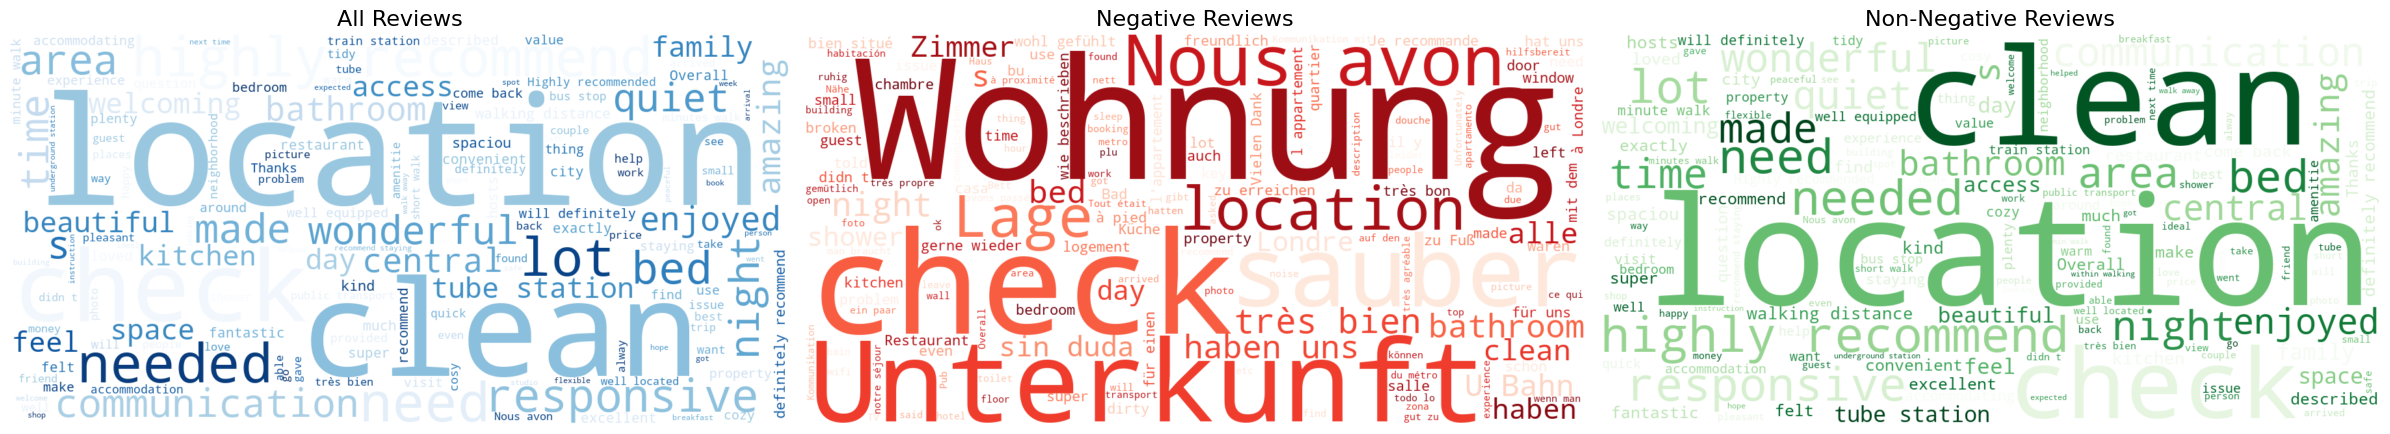

  Saved figures/word_clouds.png


In [12]:
CUSTOM_STOPWORDS = STOPWORDS.union({
    "airbnb", "place", "stay", "stayed", "host", "room", "apartment",
    "flat", "house", "would", "could", "also", "really", "one", "us",
    "london", "great", "nice", "good", "everything", "easy", "close",
    "thank", "friendly", "helpful", "comfortable", "lovely", "perfect",
    "de", "la", "le", "les", "et", "des", "une", "un", "est", "que",
    "dans", "die", "der", "das", "und", "ist", "nicht", "wir", "war",
    "sehr", "el", "en", "es", "los", "las", "una", "muy", "pero", "con",
    "br", "hst", "ck", "fr", "tro", "sm", "home",
})

fig, axes = plt.subplots(1, 3, figsize=(24, 7))

for ax, (title, subset, cmap) in zip(axes, [
    ("All Reviews", expanded["review_text"], "Blues"),
    ("Negative Reviews", expanded.loc[expanded["is_negative_review"], "review_text"], "Reds"),
    ("Non-Negative Reviews", expanded.loc[~expanded["is_negative_review"], "review_text"], "Greens"),
]):
    text = " ".join(subset.dropna().astype(str))
    wc = WordCloud(width=1200, height=600, background_color="white",
                   stopwords=CUSTOM_STOPWORDS, colormap=cmap, max_words=150).generate(text)
    ax.imshow(wc, interpolation="bilinear")
    ax.set_title(title, fontsize=16)
    ax.axis("off")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "word_clouds.png", dpi=200, bbox_inches="tight")
plt.show()
plt.close()
print("  Saved figures/word_clouds.png")

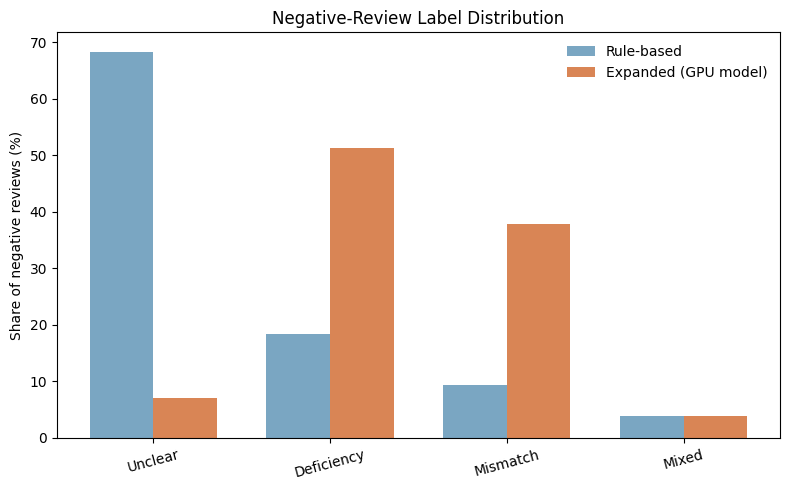

In [13]:
label_summary = pd.read_csv(OUTPUT_DIR / "label_summary.csv")
expanded_summary_df = pd.read_csv(OUTPUT_DIR / "expanded_label_summary.csv")

order = ["unclear", "deficiency", "mismatch", "mixed"]
ls = label_summary.set_index("review_label").reindex(order).reset_index()
es = expanded_summary_df.set_index("review_label").reindex(order).reset_index()

x = np.arange(len(order))
width = 0.36

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(x - width/2, ls["share_pct"], width, label="Rule-based", color="#7aa6c2")
ax.bar(x + width/2, es["share_pct"], width, label="Expanded (GPU model)", color="#d98555")
ax.set_xticks(x)
ax.set_xticklabels([s.replace("_", " ").title() for s in order], rotation=15)
ax.set_ylabel("Share of negative reviews (%)")
ax.set_title("Negative-Review Label Distribution")
ax.legend(frameon=False)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "label_distribution_comparison.png", dpi=200)
plt.show()
plt.close()

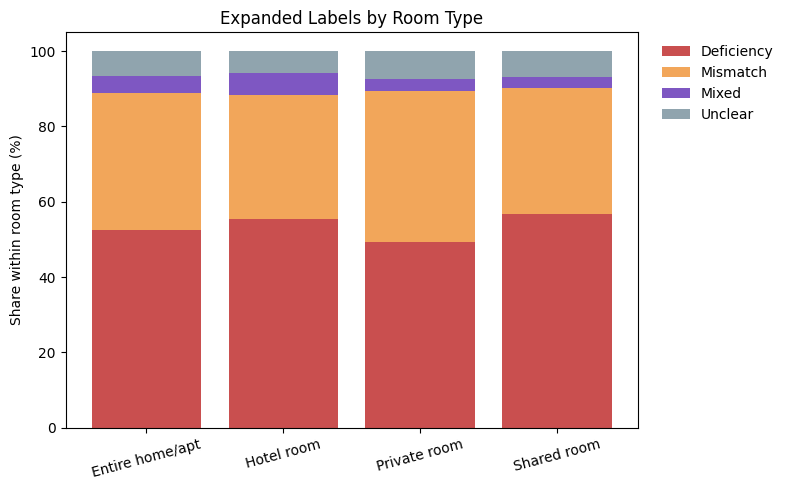

In [14]:
room = pd.read_csv(OUTPUT_DIR / "label_by_room_type.csv")
target_labels = ["deficiency", "mismatch", "mixed", "unclear"]
room = room[room["review_label"].isin(target_labels)]

pivot = room.pivot(index="room_type", columns="review_label", values="count").fillna(0)
for lbl in target_labels:
    if lbl not in pivot.columns:
        pivot[lbl] = 0
pivot = pivot[target_labels]
pct = pivot.div(pivot.sum(axis=1), axis=0) * 100

colors = ["#c94f4f", "#f2a65a", "#7e57c2", "#90a4ae"]
fig, ax = plt.subplots(figsize=(8, 5))
bottom = np.zeros(len(pct))
for col, color in zip(pct.columns, colors):
    ax.bar(pct.index, pct[col], bottom=bottom,
           label=col.replace("_", " ").title(), color=color)
    bottom += pct[col].to_numpy()

ax.set_ylabel("Share within room type (%)")
ax.set_title("Expanded Labels by Room Type")
ax.legend(frameon=False, bbox_to_anchor=(1.02, 1), loc="upper left")
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "room_type_label_mix.png", dpi=200)
plt.show()
plt.close()

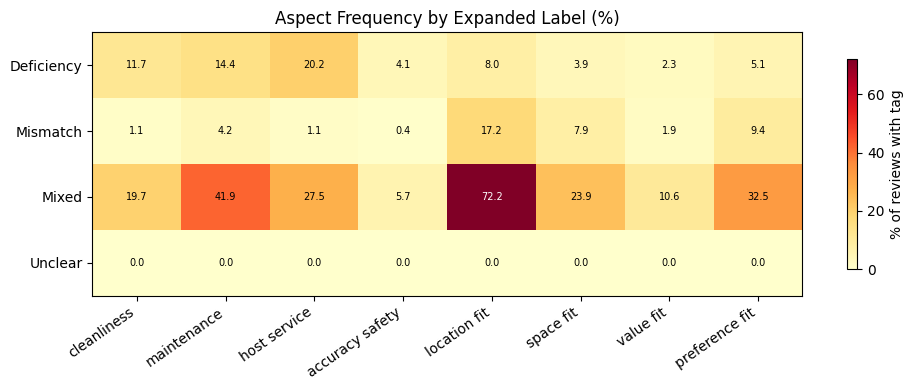

In [15]:
aspect = pd.read_csv(OUTPUT_DIR / "aspect_summary_by_label.csv")
aspect_plot = aspect.set_index("review_label")
cols = [c for c in aspect_plot.columns if c.startswith("tag_")]
aspect_plot = aspect_plot[cols]
aspect_plot.columns = [c.replace("tag_", "").replace("_", " ") for c in aspect_plot.columns]

fig, ax = plt.subplots(figsize=(10, 4))
im = ax.imshow(aspect_plot.values, cmap="YlOrRd", aspect="auto")
ax.set_xticks(range(len(aspect_plot.columns)))
ax.set_xticklabels(aspect_plot.columns, rotation=35, ha="right")
ax.set_yticks(range(len(aspect_plot.index)))
ax.set_yticklabels([i.replace("_", " ").title() for i in aspect_plot.index])
ax.set_title("Aspect Frequency by Expanded Label (%)")

for i in range(aspect_plot.shape[0]):
    for j in range(aspect_plot.shape[1]):
        v = aspect_plot.iloc[i, j]
        ax.text(j, i, f"{v:.1f}", ha="center", va="center",
                fontsize=7, color="black" if v < 60 else "white")

fig.colorbar(im, ax=ax, shrink=0.8, label="% of reviews with tag")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "aspect_heatmap.png", dpi=200)
plt.show()
plt.close()

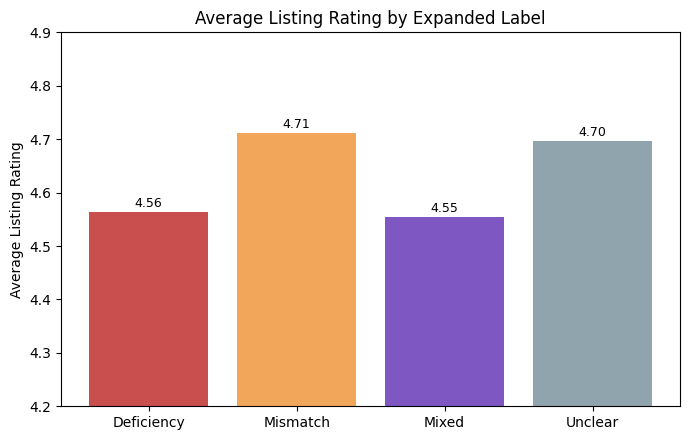

In [16]:
reviews = pd.read_csv(OUTPUT_DIR / "review_level_labels.csv")
label_col = "review_label_expanded" if "review_label_expanded" in reviews.columns else "review_label"

rating_summary = (
    reviews.groupby(label_col)["listing_review_scores_rating"]
    .agg(n_reviews="size", avg_rating="mean")
    .reindex(["deficiency", "mismatch", "mixed", "unclear"])
    .dropna()
)

fig, ax = plt.subplots(figsize=(7, 4.5))
bars = ax.bar(rating_summary.index.str.replace("_", " ").str.title(),
              rating_summary["avg_rating"],
              color=["#c94f4f", "#f2a65a", "#7e57c2", "#90a4ae"][:len(rating_summary)])
ax.set_ylabel("Average Listing Rating")
ax.set_ylim(4.2, 4.9)
ax.set_title("Average Listing Rating by Expanded Label")

for bar, v in zip(bars, rating_summary["avg_rating"]):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.01, f"{v:.2f}", ha="center", fontsize=9)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "avg_listing_rating_by_label.png", dpi=200)
plt.show()
plt.close()

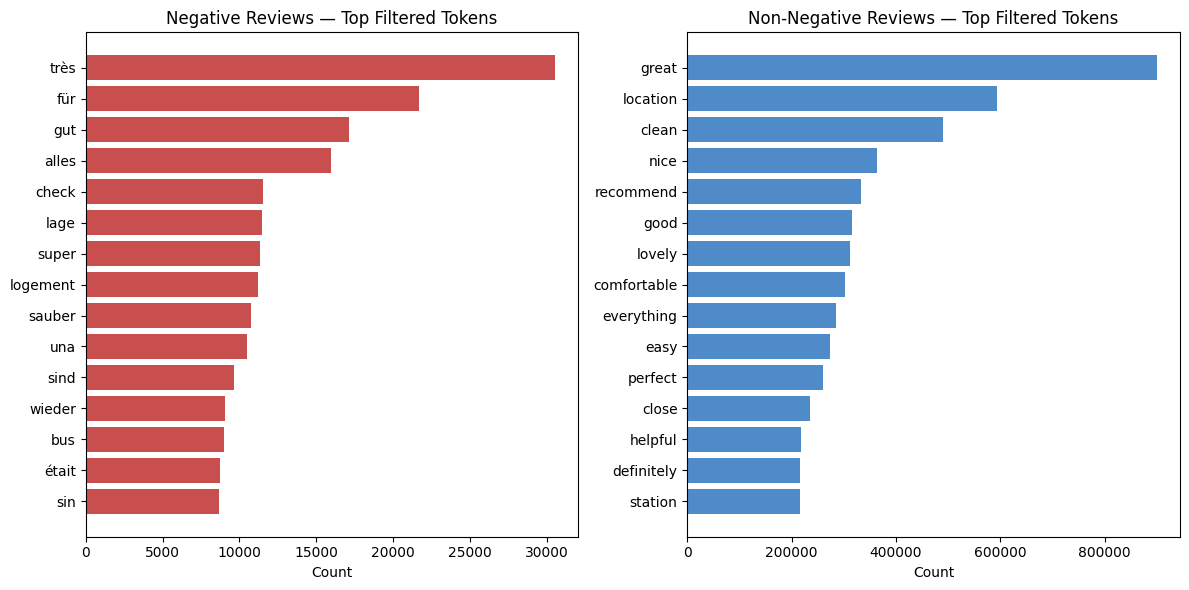

  All visualizations complete.


In [17]:
STOP_WORDS_FULL = {
    "the", "and", "for", "that", "this", "with", "was", "were", "are",
    "have", "has", "had", "very", "just", "also", "there", "from", "been",
    "into", "about", "after", "before", "they", "them", "their", "you",
    "your", "our", "ours", "not", "but", "too", "all", "any", "can",
    "could", "would", "will", "one", "two", "out", "off", "who", "what",
    "when", "where", "how", "why", "here", "again", "still", "even",
    "only", "more", "most", "much", "many", "really", "quite", "well",
    "get", "got", "made", "make", "felt", "did",
    "und", "der", "die", "das", "den", "dem", "des", "ein", "eine",
    "einer", "einem", "einen", "ist", "war", "waren", "wir", "ich",
    "mit", "auch", "sehr", "nicht", "noch", "nur", "aber", "bei", "von",
    "hat", "haben", "hatte", "zum", "zur", "aus", "auf", "im", "man", "uns",
    "et", "de", "la", "le", "les", "des", "du", "un", "une", "est", "dans",
    "pour", "avec", "sur", "pas", "plus", "nous", "vous", "ils", "elles",
    "au", "aux", "ce", "cette", "ces", "mais", "tout", "bien", "ont",
    "nos", "notre", "comme", "par", "que", "qui", "en",
    "el", "los", "las", "es", "con", "para", "por", "muy", "pero", "del",
    "como", "todo",
    "airbnb", "host", "hosts", "place", "flat", "apartment", "appartement",
    "room", "home", "house", "property", "accommodation", "stay", "stayed",
    "london", "londres", "wohnung", "zimmer", "unterkunft",
}

def clean_and_count(series, stop_words=STOP_WORDS_FULL):
    text = " ".join(series.dropna().astype(str))
    text = re.sub(r"<br\s*/?>", " ", text)
    text = re.sub(r"[^\w\s]", " ", text)
    text = re.sub(r"\s+", " ", text).lower()
    tokens = [t for t in text.split() if len(t) > 2 and t not in stop_words and not t.isdigit()]
    return Counter(tokens)

neg_counts = clean_and_count(expanded.loc[expanded["is_negative_review"], "review_text"])
pos_counts = clean_and_count(expanded.loc[~expanded["is_negative_review"], "review_text"])

neg_top = pd.DataFrame(neg_counts.most_common(15), columns=["word", "count"])
pos_top = pd.DataFrame(pos_counts.most_common(15), columns=["word", "count"])

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].barh(neg_top["word"][::-1], neg_top["count"][::-1], color="#c94f4f")
axes[0].set_title("Negative Reviews — Top Filtered Tokens")
axes[0].set_xlabel("Count")
axes[1].barh(pos_top["word"][::-1], pos_top["count"][::-1], color="#4f8bc9")
axes[1].set_title("Non-Negative Reviews — Top Filtered Tokens")
axes[1].set_xlabel("Count")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "top_words_positive_negative.png", dpi=200, bbox_inches="tight")
plt.show()
plt.close()
print("  All visualizations complete.")

## 10  Pipeline Complete

In [18]:
print("=" * 60)
print("  ANALYSIS COMPLETE")
print("=" * 60)
print(f"  Device used: {DEVICE}")
if DEVICE.type == "cuda":
    print(f"  GPU: {torch.cuda.get_device_name(0)}")
    print(f"  Peak GPU memory: {torch.cuda.max_memory_allocated()/1024**2:.0f} MB")
print(f"\n  Total reviews processed: {len(expanded):,}")
print(f"  Negative reviews: {expanded['is_negative_review'].sum():,}")
print(f"\n  Outputs: {OUTPUT_DIR}/")
print(f"  Figures: {FIGURES_DIR}/")
print(f"\n  CSV files written:")
for f in sorted(OUTPUT_DIR.glob("*.csv")):
    print(f"    {f.name}")
print(f"\n  JSON files written:")
for f in sorted(OUTPUT_DIR.glob("*.json")):
    print(f"    {f.name}")
print(f"\n  Figures saved:")
for f in sorted(FIGURES_DIR.glob("*.png")):
    print(f"    {f.name}")

  ANALYSIS COMPLETE
  Device used: cuda
  GPU: NVIDIA GeForce RTX 3050 Laptop GPU
  Peak GPU memory: 306 MB

  Total reviews processed: 2,097,795
  Negative reviews: 105,365

  Outputs: airbnb_mismatch_outputs/
  Figures: figures/

  CSV files written:
    aspect_summary_by_label.csv
    example_reviews_by_label.csv
    expanded_label_summary.csv
    label_by_room_type.csv
    label_summary.csv
    review_level_labels.csv

  JSON files written:
    headline_summary.json
    text_model_metrics.json

  Figures saved:
    aspect_heatmap.png
    avg_listing_rating_by_label.png
    label_distribution_comparison.png
    room_type_label_mix.png
    top_words_positive_negative.png
    word_clouds.png
